In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Charger les données prétraitées
X = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\processed\X_processed.csv')
y = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\processed\y_processed.csv')

print(f"✅ Données chargées !")
print(f"👉 X : {X.shape}")
print(f"👉 y : {y.shape}")

✅ Données chargées !
👉 X : (4372, 70)
👉 y : (4372, 1)


k=2 ✅
k=3 ✅
k=4 ✅
k=5 ✅
k=6 ✅
k=7 ✅
k=8 ✅
k=9 ✅
k=10 ✅


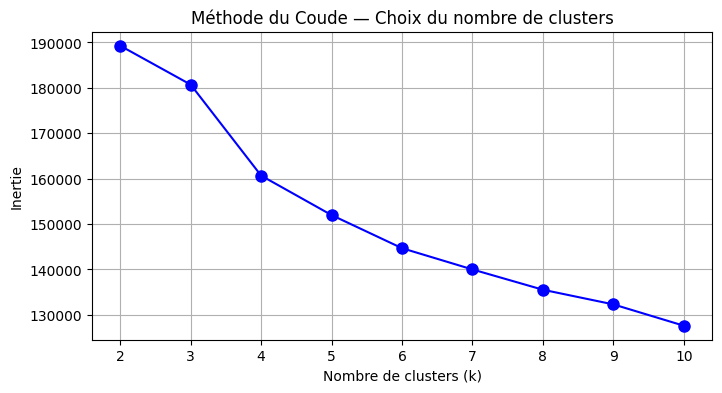

In [3]:
# Tester différents nombres de clusters
inerties = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inerties.append(kmeans.inertia_)
    print(f"k={k} ✅")

# Visualiser le coude
plt.figure(figsize=(8, 4))
plt.plot(K, inerties, 'bo-', markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude — Choix du nombre de clusters')
plt.xticks(K)
plt.grid(True)
plt.show()

In [4]:
# Appliquer K-Means avec 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

# Ajouter les clusters au dataframe
X['Cluster'] = kmeans.labels_

print("✅ Clustering terminé !")
print(f"\nRépartition des clients par cluster :")
print(X['Cluster'].value_counts().sort_index())

✅ Clustering terminé !

Répartition des clients par cluster :
Cluster
0    1573
1    2780
2       2
3      17
Name: count, dtype: int64


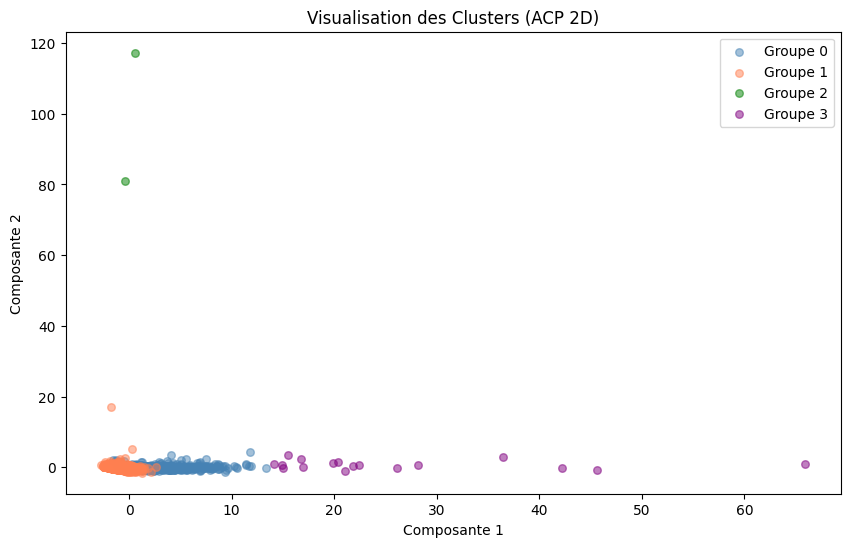


Variance expliquée par les 2 composantes : 25.2%


In [5]:
# Réduire à 2 dimensions avec ACP
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.drop(columns=['Cluster']))

# Visualiser
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral', 'green', 'purple']
labels = ['Groupe 0', 'Groupe 1', 'Groupe 2', 'Groupe 3']

for i in range(4):
    mask = X['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i], label=labels[i], alpha=0.5, s=30)

plt.title('Visualisation des Clusters (ACP 2D)')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.legend()
plt.show()

print(f"\nVariance expliquée par les 2 composantes : {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [6]:
# Étape 1 : Réduire à 10 composantes (garder ~90% de l'info)
pca = PCA(n_components=10, random_state=42)
X_reduit = pca.fit_transform(X.drop(columns=['Cluster']))

print(f"Variance expliquée : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Étape 2 : K-Means sur les données réduites
kmeans2 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans2.fit(X_reduit)

# Étape 3 : Voir les résultats
X['Cluster_v2'] = kmeans2.labels_
print(f"\nRépartition des clusters :")
print(X['Cluster_v2'].value_counts().sort_index())

Variance expliquée : 59.6%

Répartition des clusters :
Cluster_v2
0      17
1    1600
2       2
3    2753
Name: count, dtype: int64


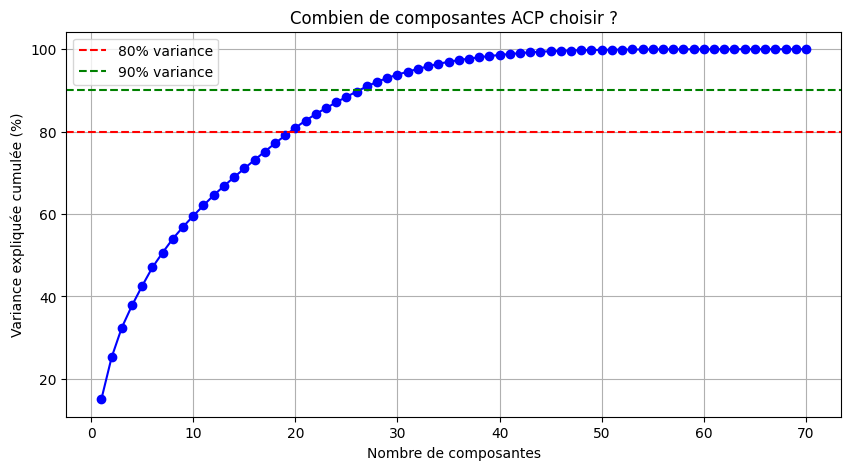

Composantes pour 80% de variance : 20
Composantes pour 90% de variance : 27


In [7]:
# Tester combien de composantes donnent assez d'information
pca_full = PCA(random_state=42)
pca_full.fit(X.drop(columns=['Cluster', 'Cluster_v2']))

# Variance cumulée
variance_cumulee = pca_full.explained_variance_ratio_.cumsum() * 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(variance_cumulee)+1), variance_cumulee, 'bo-')
plt.axhline(y=80, color='red', linestyle='--', label='80% variance')
plt.axhline(y=90, color='green', linestyle='--', label='90% variance')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée (%)')
plt.title('Combien de composantes ACP choisir ?')
plt.legend()
plt.grid(True)
plt.show()

# Trouver le nombre exact pour 80% et 90%
n_80 = next(i for i, v in enumerate(variance_cumulee) if v >= 80) + 1
n_90 = next(i for i, v in enumerate(variance_cumulee) if v >= 90) + 1
print(f"Composantes pour 80% de variance : {n_80}")
print(f"Composantes pour 90% de variance : {n_90}")

In [8]:
# ACP avec 27 composantes (90% variance)
pca_final = PCA(n_components=27, random_state=42)
X_reduit_final = pca_final.fit_transform(
    X.drop(columns=['Cluster', 'Cluster_v2'])
)

print(f"✅ Variance expliquée : {pca_final.explained_variance_ratio_.sum()*100:.1f}%")
print(f"👉 Dimensions réduites : {X_reduit_final.shape}")

# K-Means sur les données réduites
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_final.fit(X_reduit_final)

# Ajouter les clusters
X['Cluster_final'] = kmeans_final.labels_

print(f"\n✅ Clustering final terminé !")
print(f"\nRépartition des clients par cluster :")
print(X['Cluster_final'].value_counts().sort_index())

✅ Variance expliquée : 91.0%
👉 Dimensions réduites : (4372, 27)

✅ Clustering final terminé !

Répartition des clients par cluster :
Cluster_final
0      17
1    1600
2    2753
3       2
Name: count, dtype: int64


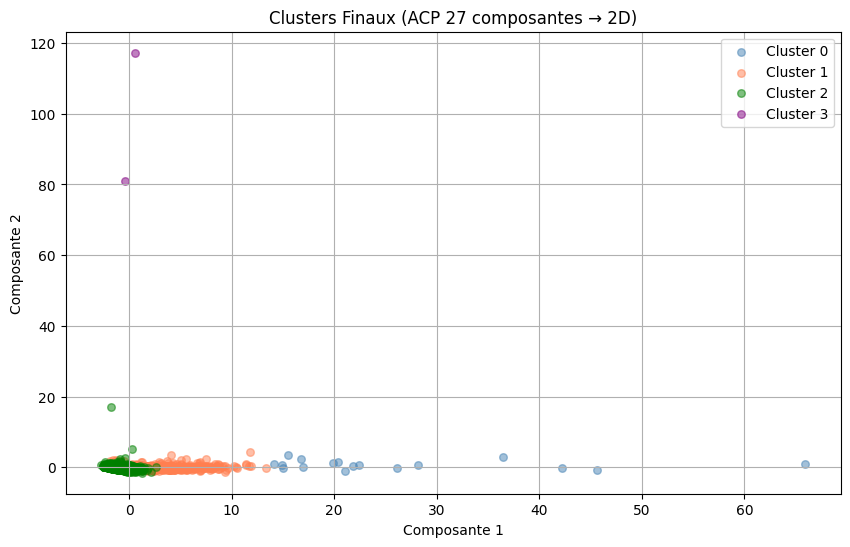

In [9]:
# Réduire à 2D juste pour la visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_reduit_final)

plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral', 'green', 'purple']

for i in range(4):
    mask = X['Cluster_final'] == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.5, s=30)

plt.title('Clusters Finaux (ACP 27 composantes → 2D)')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
from scipy import stats

# Supprimer les lignes où on utilise les données réduites
X_temp = X.drop(columns=['Cluster', 'Cluster_v2', 'Cluster_final'])

# Détecter les outliers avec le Z-score
z_scores = np.abs(stats.zscore(X_temp))
outliers_mask = (z_scores > 4).any(axis=1)

print(f"Outliers détectés : {outliers_mask.sum()} clients")
print(f"Clients normaux   : {(~outliers_mask).sum()} clients")

# Garder uniquement les clients normaux
X_clean = X_temp[~outliers_mask]
print(f"\n✅ Dataset nettoyé : {X_clean.shape}")

AttributeError: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'

In [11]:
from scipy import stats

# Supprimer les colonnes de clustering
X_temp = X.drop(columns=['Cluster', 'Cluster_v2', 'Cluster_final'])

# Convertir les booléens en entiers (True→1, False→0)
X_temp = X_temp.astype(float)

# Détecter les outliers avec le Z-score
z_scores = np.abs(stats.zscore(X_temp))
outliers_mask = (z_scores > 4).any(axis=1)

print(f"Outliers détectés : {outliers_mask.sum()} clients")
print(f"Clients normaux   : {(~outliers_mask).sum()} clients")

# Garder uniquement les clients normaux
X_clean = X_temp[~outliers_mask]
print(f"\n✅ Dataset nettoyé : {X_clean.shape}")

Outliers détectés : 771 clients
Clients normaux   : 3601 clients

✅ Dataset nettoyé : (3601, 70)


In [12]:
# ACP sur données propres
pca_clean = PCA(n_components=27, random_state=42)
X_clean_pca = pca_clean.fit_transform(X_clean)

print(f"Variance expliquée : {pca_clean.explained_variance_ratio_.sum()*100:.1f}%")

# K-Means
kmeans_clean = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_clean.fit(X_clean_pca)

X_clean = X_clean.copy()
X_clean['Cluster'] = kmeans_clean.labels_

print(f"\nRépartition des clusters :")
print(X_clean['Cluster'].value_counts().sort_index())

Variance expliquée : 96.2%

Répartition des clusters :
Cluster
0     907
1    1167
2     426
3    1101
Name: count, dtype: int64


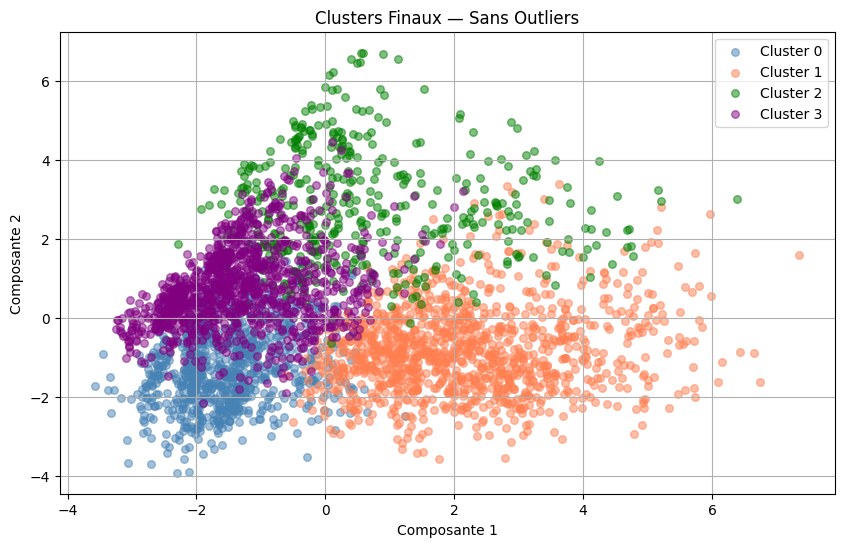

In [13]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_clean_pca)

plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral', 'green', 'purple']

for i in range(4):
    mask = X_clean['Cluster'] == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                alpha=0.5, s=30)

plt.title('Clusters Finaux — Sans Outliers')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Recharger les données originales
df_original = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\raw\retail_customers_COMPLETE_CATEGORICAL.csv')

# Ajouter les clusters aux données originales
df_original = df_original[~outliers_mask].copy()
df_original['Cluster'] = kmeans_clean.labels_

# Analyser chaque cluster
profils = df_original.groupby('Cluster')[['Recency', 'Frequency', 
                                           'MonetaryTotal', 'Age']].mean().round(1)
print("📊 Profil moyen de chaque cluster :")
print(profils)

📊 Profil moyen de chaque cluster :
         Recency  Frequency  MonetaryTotal   Age
Cluster                                         
0          226.7        2.0          493.3  48.8
1           29.9        8.7         2736.4  49.5
2           93.1        3.0          772.1  49.0
3           43.0        2.3          697.5  48.9


In [16]:
churn_cluster = df_original.groupby('Cluster')['Churn'].mean().round(3) * 100
print("⚠️ Taux de churn par cluster (%) :")
print(churn_cluster)

⚠️ Taux de churn par cluster (%) :
Cluster
0    99.8
1     4.0
2    35.7
3     6.5
Name: Churn, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             accuracy_score,
                             roc_auc_score,
                             roc_curve)
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Charger les données
X_train = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\X_train.csv')
X_test  = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\X_test.csv')
y_train = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\y_train.csv').squeeze()
y_test  = pd.read_csv(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\data\train_test\y_test.csv').squeeze()

print("✅ Données chargées !")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nRépartition Churn (train) :")
print(y_train.value_counts())

✅ Données chargées !
X_train : (3497, 67)
X_test  : (875, 67)

Répartition Churn (train) :
Churn
0    2334
1    1163
Name: count, dtype: int64


In [3]:
# Modèle 1 : Régression Logistique
lr = LogisticRegression(class_weight='balanced', 
                         max_iter=1000, 
                         random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("✅ Régression Logistique entraînée !")
print(f"\nAccuracy : {accuracy_score(y_test, y_pred_lr)*100:.1f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_pred_lr)*100:.1f}%")
print(f"\nRapport détaillé :")
print(classification_report(y_test, y_pred_lr))

✅ Régression Logistique entraînée !

Accuracy : 99.9%
AUC-ROC  : 99.9%

Rapport détaillé :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875



In [5]:
# Modèle 2 : Random Forest
rf = RandomForestClassifier(class_weight='balanced',
                             n_estimators=100,
                             random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("✅ Random Forest entraîné !")
print(f"\nAccuracy : {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_pred_rf)*100:.1f}%")
print(f"\nRapport détaillé :")
print(classification_report(y_test, y_pred_rf))

✅ Random Forest entraîné !

Accuracy : 100.0%
AUC-ROC  : 100.0%

Rapport détaillé :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875



In [6]:
# Colonnes qui "trichent" car elles révèlent le Churn
leaky_cols = [col for col in X_train.columns if any(
    leak in col for leak in [
        'ChurnRisk', 'Churn',
        'AccountStatus_Closed',
        'AccountStatus_Suspended'
    ]
)]

print("Colonnes suspectes trouvées :")
for col in leaky_cols:
    print(f"  - {col}")

Colonnes suspectes trouvées :
  - ChurnRiskCategory
  - AccountStatus_Closed
  - AccountStatus_Suspended


In [7]:
# Supprimer les colonnes leaky
X_train_clean = X_train.drop(columns=leaky_cols)
X_test_clean  = X_test.drop(columns=leaky_cols)

print(f"✅ Colonnes suspectes supprimées !")
print(f"👉 X_train : {X_train_clean.shape}")
print(f"👉 X_test  : {X_test_clean.shape}")

✅ Colonnes suspectes supprimées !
👉 X_train : (3497, 64)
👉 X_test  : (875, 64)


In [8]:
# Modèle 1 : Régression Logistique
lr = LogisticRegression(class_weight='balanced',
                         max_iter=1000,
                         random_state=42)
lr.fit(X_train_clean, y_train)
y_pred_lr = lr.predict(X_test_clean)

print("=== Régression Logistique ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.1f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_pred_lr)*100:.1f}%")
print(classification_report(y_test, y_pred_lr))

# Modèle 2 : Random Forest
rf = RandomForestClassifier(class_weight='balanced',
                             n_estimators=100,
                             random_state=42)
rf.fit(X_train_clean, y_train)
y_pred_rf = rf.predict(X_test_clean)

print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_pred_rf)*100:.1f}%")
print(classification_report(y_test, y_pred_rf))

=== Régression Logistique ===
Accuracy : 99.9%
AUC-ROC  : 99.8%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875

=== Random Forest ===
Accuracy : 100.0%
AUC-ROC  : 100.0%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875



In [9]:
# Calculer la corrélation de chaque feature avec le Churn
y_train_series = y_train.squeeze()

correlations = X_train_clean.corrwith(y_train_series).abs().sort_values(ascending=False)

print("Top 20 features les plus corrélées avec Churn :")
print(correlations.head(20).round(3))

Top 20 features les plus corrélées avec Churn :
Recency                     0.859
CustomerType_Perdu          0.699
TenureRatio                 0.567
CustomerTenureDays          0.453
CustomerType_Occasionnel    0.432
PreferredMonth              0.427
AvgBasketValue              0.309
CustomerType_Régulier       0.307
FavoriteSeason_Printemps    0.302
ProductDiversity            0.300
UniqueProducts              0.265
CustomerType_Nouveau        0.232
LoyaltyLevel                0.222
FirstPurchaseDaysAgo        0.219
Frequency                   0.217
FavoriteSeason_Hiver        0.204
RFMSegment                  0.179
FavoriteSeason_Été          0.174
TotalQuantity               0.141
NegativeQuantityCount       0.129
dtype: float64


In [10]:
# Supprimer les colonnes qui révèlent directement le Churn
leaky_cols_2 = [
    'CustomerType_Perdu',  # = client perdu = churné !
    'Recency',             # trop directement lié au Churn
    'TenureRatio',         # calculé depuis Recency
    'CustomerTenureDays',  # trop lié au Churn
    'FirstPurchaseDaysAgo' # trop lié au Churn
]

# Supprimer
cols_to_drop = [c for c in leaky_cols_2 if c in X_train_clean.columns]
X_train_clean2 = X_train_clean.drop(columns=cols_to_drop)
X_test_clean2  = X_test_clean.drop(columns=cols_to_drop)

print(f"✅ Colonnes supprimées : {cols_to_drop}")
print(f"👉 X_train : {X_train_clean2.shape}")
print(f"👉 X_test  : {X_test_clean2.shape}")

# Vérifier les nouvelles corrélations
correlations2 = X_train_clean2.corrwith(y_train.squeeze()).abs().sort_values(ascending=False)
print(f"\nTop 10 corrélations restantes :")
print(correlations2.head(10).round(3))

✅ Colonnes supprimées : ['CustomerType_Perdu', 'Recency', 'TenureRatio', 'CustomerTenureDays', 'FirstPurchaseDaysAgo']
👉 X_train : (3497, 59)
👉 X_test  : (875, 59)

Top 10 corrélations restantes :
CustomerType_Occasionnel    0.432
PreferredMonth              0.427
AvgBasketValue              0.309
CustomerType_Régulier       0.307
FavoriteSeason_Printemps    0.302
ProductDiversity            0.300
UniqueProducts              0.265
CustomerType_Nouveau        0.232
LoyaltyLevel                0.222
Frequency                   0.217
dtype: float64


In [11]:
# Modèle 1 : Régression Logistique
lr = LogisticRegression(class_weight='balanced',
                         max_iter=1000,
                         random_state=42)
lr.fit(X_train_clean2, y_train)
y_pred_lr = lr.predict(X_test_clean2)

print("=== Régression Logistique ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.1f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_pred_lr)*100:.1f}%")
print(classification_report(y_test, y_pred_lr))

# Modèle 2 : Random Forest
rf = RandomForestClassifier(class_weight='balanced',
                             n_estimators=100,
                             random_state=42)
rf.fit(X_train_clean2, y_train)
y_pred_rf = rf.predict(X_test_clean2)

print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_pred_rf)*100:.1f}%")
print(classification_report(y_test, y_pred_rf))

=== Régression Logistique ===
Accuracy : 97.0%
AUC-ROC  : 96.8%
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       584
           1       0.95      0.96      0.96       291

    accuracy                           0.97       875
   macro avg       0.97      0.97      0.97       875
weighted avg       0.97      0.97      0.97       875

=== Random Forest ===
Accuracy : 99.5%
AUC-ROC  : 99.3%
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       584
           1       1.00      0.99      0.99       291

    accuracy                           1.00       875
   macro avg       1.00      0.99      0.99       875
weighted avg       1.00      1.00      1.00       875



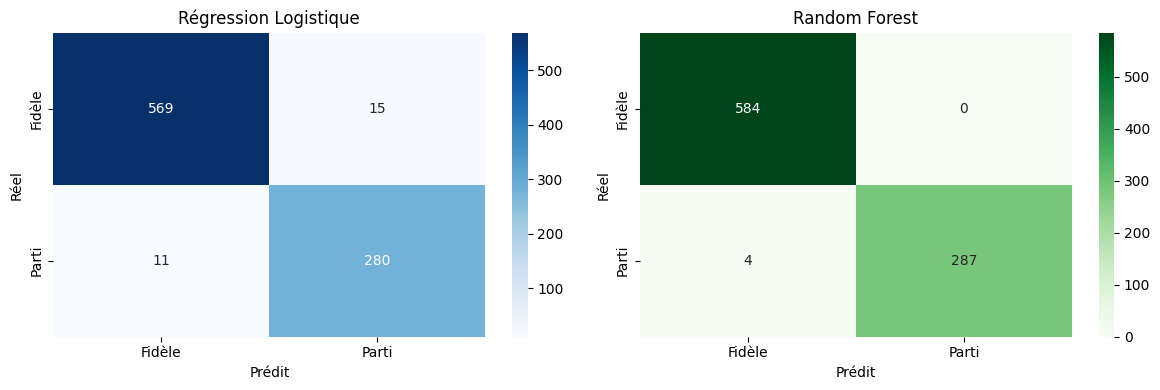

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matrice de confusion LR
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fidèle', 'Parti'],
            yticklabels=['Fidèle', 'Parti'], ax=axes[0])
axes[0].set_title('Régression Logistique')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# Matrice de confusion RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fidèle', 'Parti'],
            yticklabels=['Fidèle', 'Parti'], ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')

plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV

# Paramètres à tester
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

print("⏳ Recherche des meilleurs paramètres...")
print("(Ça peut prendre 2-3 minutes, c'est normal !)")

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,              # 5 validations croisées
    scoring='roc_auc', # Optimiser l'AUC-ROC
    n_jobs=-1,         # Utiliser tous les processeurs
    verbose=1
)

grid_search.fit(X_train_clean2, y_train)

print(f"\n✅ Meilleurs paramètres trouvés :")
print(grid_search.best_params_)
print(f"\nMeilleur score AUC-ROC : {grid_search.best_score_*100:.1f}%")

⏳ Recherche des meilleurs paramètres...
(Ça peut prendre 2-3 minutes, c'est normal !)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Meilleurs paramètres trouvés :
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Meilleur score AUC-ROC : 99.9%


In [14]:
# Entraîner avec les meilleurs paramètres
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_clean2)

print("=== Meilleur Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best)*100:.1f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_pred_best)*100:.1f}%")
print(classification_report(y_test, y_pred_best))

=== Meilleur Random Forest ===
Accuracy : 99.4%
AUC-ROC  : 99.1%
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       584
           1       1.00      0.98      0.99       291

    accuracy                           0.99       875
   macro avg       1.00      0.99      0.99       875
weighted avg       0.99      0.99      0.99       875



In [15]:
import joblib
import os

# Créer le dossier models/
os.makedirs(r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\models', exist_ok=True)

# Sauvegarder le modèle
joblib.dump(best_rf, r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\models\random_forest_churn.joblib')

# Sauvegarder aussi la liste des colonnes utilisées
joblib.dump(X_train_clean2.columns.tolist(), r'C:\Users\rabdelmoula\Documents\Machine-Learning\projet_ml_retail\models\feature_columns.joblib')

print("✅ Modèle sauvegardé dans models/")
print(f"   - random_forest_churn.joblib")
print(f"   - feature_columns.joblib")

✅ Modèle sauvegardé dans models/
   - random_forest_churn.joblib
   - feature_columns.joblib


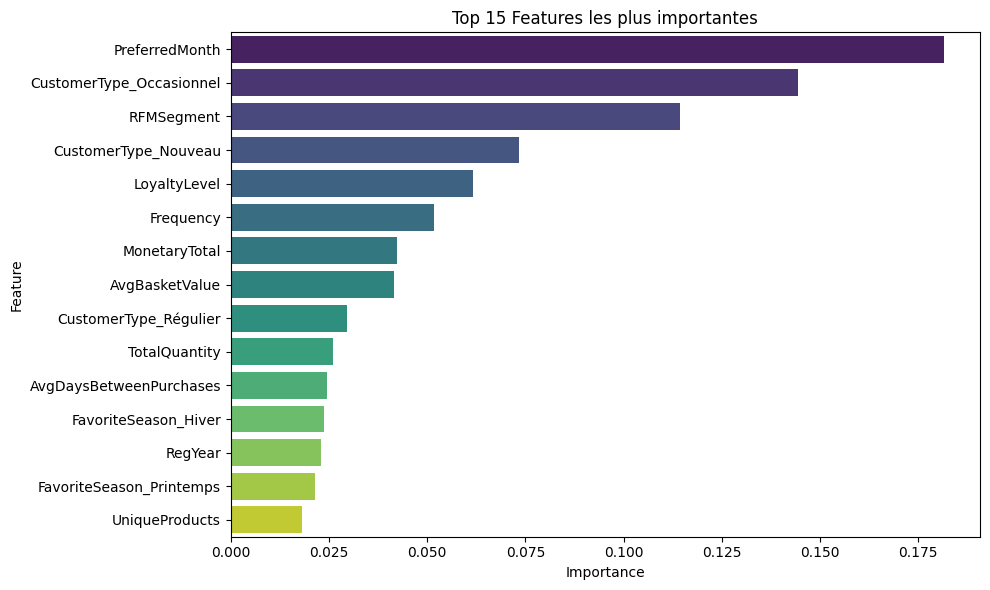

                     Feature  Importance
10            PreferredMonth    0.181610
36  CustomerType_Occasionnel    0.144478
23                RFMSegment    0.114290
35      CustomerType_Nouveau    0.073452
27              LoyaltyLevel    0.061747
1                  Frequency    0.051823
2              MonetaryTotal    0.042224
56            AvgBasketValue    0.041469
37     CustomerType_Régulier    0.029637
5              TotalQuantity    0.026138
12   AvgDaysBetweenPurchases    0.024373
38      FavoriteSeason_Hiver    0.023706
31                   RegYear    0.022986
39  FavoriteSeason_Printemps    0.021369
13            UniqueProducts    0.018143


In [16]:
importances = pd.DataFrame({
    'Feature': X_train_clean2.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Features les plus importantes')
plt.tight_layout()
plt.show()

print(importances)